# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Muhamaf Nafi Mulyo | 5054251005 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [22]:
# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("--- 5 Baris Pertama ---")
display(df.head())

print("\n--- Info Tipe Data ---")
df.info()

print("\n--- Missing Value Awal ---")
print(df.isnull().sum())


--- 5 Baris Pertama ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Info Tipe Data ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

/tmp/ipykernel_55149/710604738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


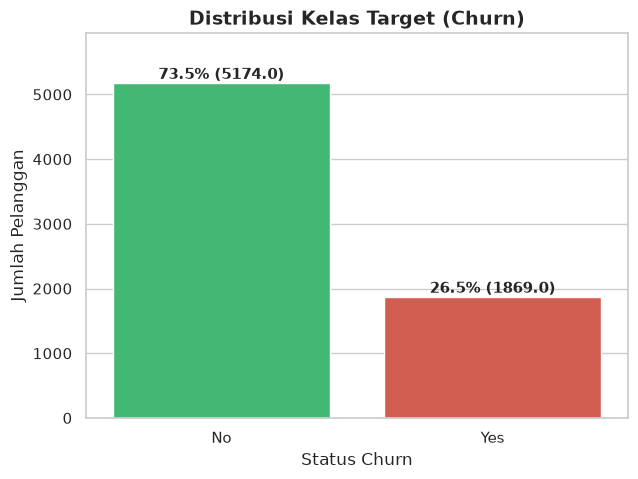

Rasio Kelas (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [23]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Kelas Target (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Status Churn')
plt.ylabel('Jumlah Pelanggan')

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}% ({height})'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height + 10),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(df['Churn'].value_counts()) * 1.15)
plt.show()

print("Rasio Kelas (%):")
print(df['Churn'].value_counts(normalize=True) * 100)


/tmp/ipykernel_55149/3022956496.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'], ax=axes[1])


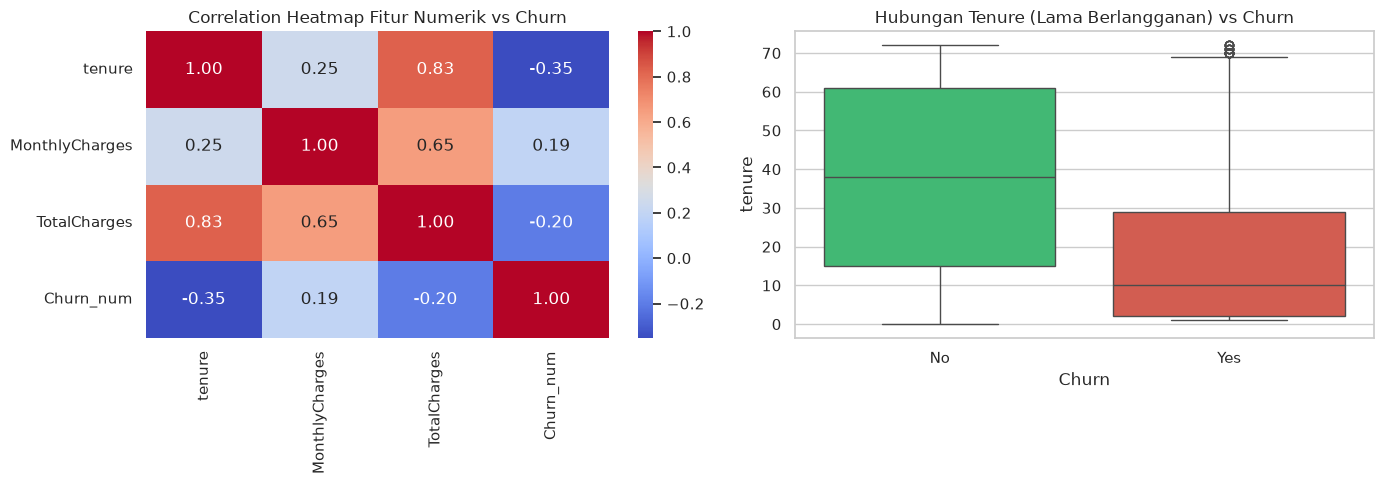

In [24]:
# Bersihkan sementara TotalCharges untuk visualisasi korelasi
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'].str.strip(), errors='coerce')
df_eda['Churn_num'] = df_eda['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap Korelasi Fitur Numerik vs Target
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
sns.heatmap(df_eda[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('Correlation Heatmap Fitur Numerik vs Churn')

# 2. Boxplot Tenure vs Churn
sns.boxplot(data=df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Hubungan Tenure (Lama Berlangganan) vs Churn')

plt.tight_layout()
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [25]:
# 1. Drop customerID (ID unik tidak relevan untuk pola NN)
df_clean = df.drop(columns=['customerID'])

# 2. Konversi TotalCharges dari string ke numeric (spasi kosong jadi NaN)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].str.strip(), errors='coerce')

print("Jumlah NaN di TotalCharges setelah konversi:", df_clean['TotalCharges'].isnull().sum())

# 3. Fill NaN pada TotalCharges dengan 0 (karena pelanggan baru tenure=0 belum pernah bayar total)
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

print("Total missing values tersisa:", df_clean.isnull().sum().sum())


Jumlah NaN di TotalCharges setelah konversi: 11
Total missing values tersisa: 0


In [28]:
# 1. Encode Target 'Churn': Yes -> 1, No -> 0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 2. One-Hot Encoding untuk seluruh kolom kategorikal
df_encoded = pd.get_dummies(df_clean, drop_first=True)

print("Bentuk dataset setelah One-Hot Encoding:", df_encoded.shape)
display(df_encoded.head(3))


Bentuk dataset setelah One-Hot Encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [29]:
# Split X dan y
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Train-Test Split 80:20 dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Train : {X_train.shape[0]} baris, {X_train.shape[1]} fitur")
print(f"Data Test  : {X_test.shape[0]} baris, {X_test.shape[1]} fitur")


Data Train : 5634 baris, 30 fitur
Data Test  : 1409 baris, 30 fitur


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [30]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# fit_transform pada X_train, transform saja pada X_test (mencegah Data Leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler berhasil!")
print("Cek Mean X_train_scaled (harus ~0):", np.mean(X_train_scaled[:, 0]).round(4))
print("Cek Std  X_train_scaled (harus 1.0):", np.std(X_train_scaled[:, 0]).round(4))


StandardScaler berhasil!
Cek Mean X_train_scaled (harus ~0): 0.0
Cek Std  X_train_scaled (harus 1.0): 1.0


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [31]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
# 1. Inisialisasi & latih MLPClassifier baseline
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
mlp_base.fit(X_train_scaled, y_train)

# 2. Prediksi & hitung akurasi
acc_train_base = accuracy_score(y_train, mlp_base.predict(X_train_scaled))
acc_test_base = accuracy_score(y_test, mlp_base.predict(X_test_scaled))

print("=== 3.1 Baseline ANN (10 Neuron, ReLU) ===")
print(f"Akurasi Training : {acc_train_base * 100:.2f}%")
print(f"Akurasi Testing  : {acc_test_base * 100:.2f}%")


=== 3.1 Baseline ANN (10 Neuron, ReLU) ===
Akurasi Training : 82.00%
Akurasi Testing  : 78.78%


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [32]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
activations = ['relu', 'tanh', 'logistic']
activation_results = []

for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_test = accuracy_score(y_test, model.predict(X_test_scaled))
    
    activation_results.append({
        'Fungsi Aktivasi': act.upper(),
        'Akurasi Training': f"{acc_train * 100:.2f}%",
        'Akurasi Testing': f"{acc_test * 100:.2f}%",
        'Jumlah Iterasi (Converge)': model.n_iter_
    })

df_act = pd.DataFrame(activation_results)
display(df_act)


,Fungsi Aktivasi,Akurasi Training,Akurasi Testing,Jumlah Iterasi (Converge)
0,RELU,82.00%,78.78%,241
1,TANH,82.46%,79.35%,431
2,LOGISTIC,81.56%,79.28%,479


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

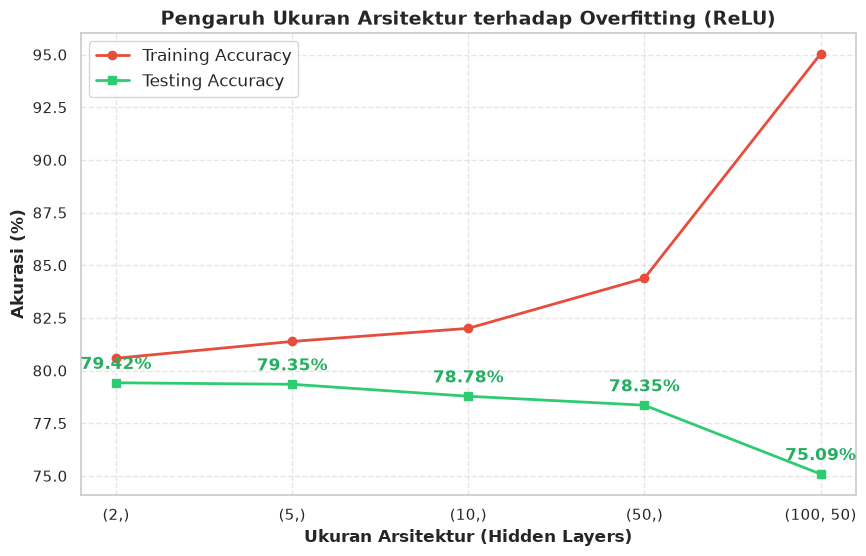

In [33]:
architectures = [(2,), (5,), (10,), (50,), (100, 50)]
arch_labels = ['(2,)', '(5,)', '(10,)', '(50,)', '(100, 50)']

train_accs = []
test_accs = []

for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation='relu', max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_accs.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test, model.predict(X_test_scaled)))

# Plot Akurasi Training vs Testing terhadap Ukuran Arsitektur
plt.figure(figsize=(10, 6))
plt.plot(arch_labels, [a * 100 for a in train_accs], marker='o', label='Training Accuracy', linewidth=2, color='#e74c3c')
plt.plot(arch_labels, [a * 100 for a in test_accs], marker='s', label='Testing Accuracy', linewidth=2, color='#2ecc71')

plt.xlabel('Ukuran Arsitektur (Hidden Layers)', fontsize=12, fontweight='bold')
plt.ylabel('Akurasi (%)', fontsize=12, fontweight='bold')
plt.title('Pengaruh Ukuran Arsitektur terhadap Overfitting (ReLU)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, ls="--", alpha=0.5)

for idx, arch_str in enumerate(arch_labels):
    plt.annotate(f"{test_accs[idx]*100:.2f}%", (arch_str, test_accs[idx]*100), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#27ae60')

plt.show()


# 4. Evaluasi Model

In [34]:
# Model Terbaik (Arsitektur Simpel 5 Neuron) vs Model Overfit (100, 50)
model_best = MLPClassifier(hidden_layer_sizes=(5,), activation='tanh', max_iter=500, random_state=42).fit(X_train_scaled, y_train)
model_overfit = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', max_iter=500, random_state=42).fit(X_train_scaled, y_train)

metrics_ann = []
for name, model in [('MLP (5,) Tanh [Best]', model_best), ('MLP (100, 50) ReLU [Overfit]', model_overfit)]:
    y_pred = model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    metrics_ann.append({
        'Arsitektur Model': name,
        'Accuracy': f"{report['accuracy']*100:.2f}%",
        'Precision (Churn)': f"{report['1']['precision']*100:.2f}%",
        'Recall (Churn)': f"{report['1']['recall']*100:.2f}%",
        'F1-Score (Churn)': f"{report['1']['f1-score']*100:.2f}%"
    })

df_eval_ann = pd.DataFrame(metrics_ann)
display(df_eval_ann)


,Arsitektur Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
0,"MLP (5,) Tanh [Best]",79.06%,62.78%,51.87%,56.81%
1,"MLP (100, 50) ReLU [Overfit]",75.09%,53.15%,51.87%,52.50%


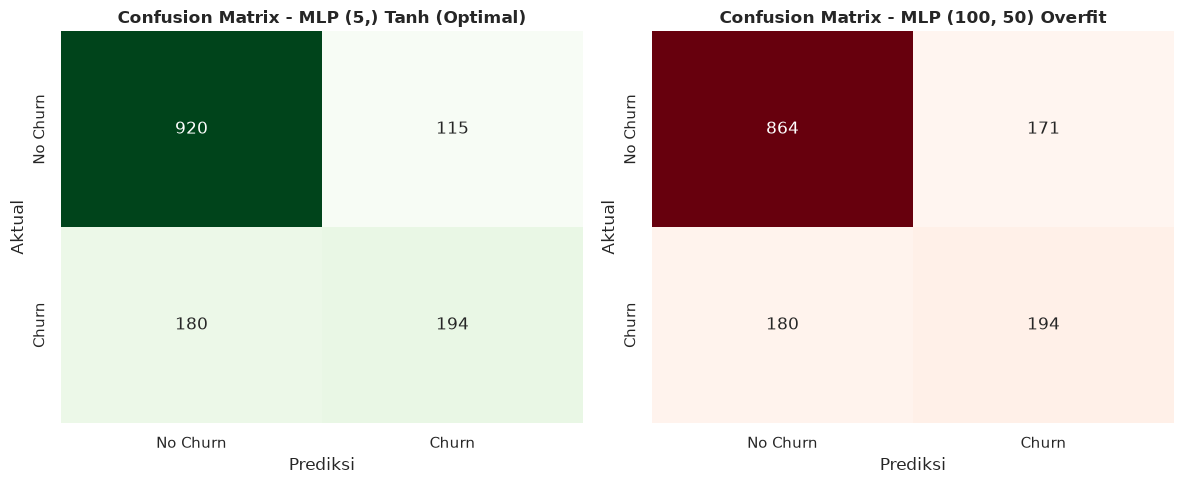

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_best = confusion_matrix(y_test, model_best.predict(X_test_scaled))
cm_overfit = confusion_matrix(y_test, model_overfit.predict(X_test_scaled))

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix - MLP (5,) Tanh (Optimal)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

sns.heatmap(cm_overfit, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Confusion Matrix - MLP (100, 50) Overfit', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()


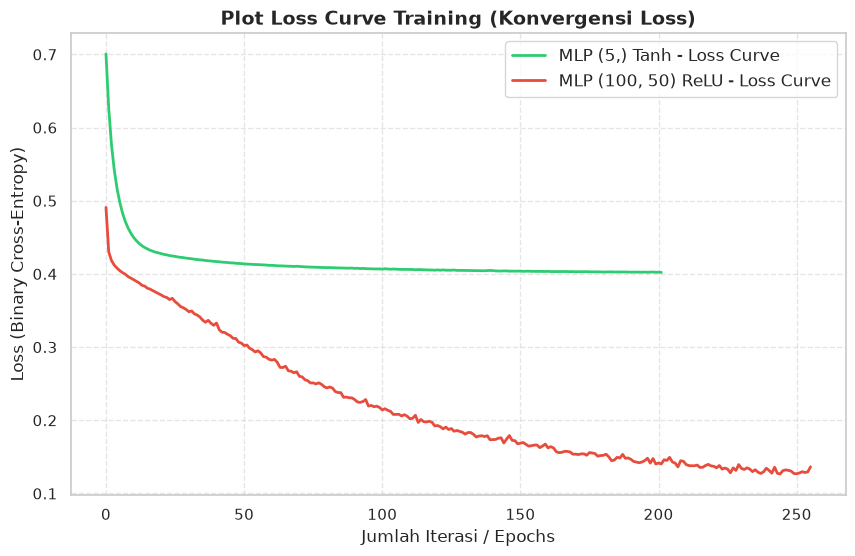

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(model_best.loss_curve_, label='MLP (5,) Tanh - Loss Curve', linewidth=2, color='#2ecc71')
plt.plot(model_overfit.loss_curve_, label='MLP (100, 50) ReLU - Loss Curve', linewidth=2, color='#e74c3c')

plt.title('Plot Loss Curve Training (Konvergensi Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Iterasi / Epochs', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, ls="--", alpha=0.5)
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

1. Perbandingan Fungsi Aktivasi (ReLU vs Tanh vs Logistic):
   - Ketiga fungsi aktivasi memberikan akurasi testing yang mirip (~78.7% - 79.3%).
   - ReLU mengungguli Tanh dan Logistic dalam kecepatan konvergensi (hanya butuh 241 iterasi dibanding 431 dan 479 iterasi). Hal ini disebabkan oleh sifat ReLU yang tidak mengalami Vanishing Gradient pada region positif.

2. Pengaruh Ukuran Arsitektur terhadap Overfitting:
   - Arsitektur kecil seperti (2,) dan (5,) menghasilkan performa generalisasi terbaik pada test set (~79.4%).
   - Meningkatkan kapasitas model hingga (100, 50) menyebabkan Overfitting parah, di mana akurasi training melonjak ke 95.0% namun akurasi testing anjlok ke 75.09%. Hal ini terjadi karena parameter bobot yang terlalu banyak (9000+) membuat model menghafal noise data training.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulan:
1. Feature scaling (StandardScaler) sangat penting agar update gradien pada backpropagation berlangsung stabil dan adil di seluruh atribut input.
2. Arsitektur ANN yang lebih kompleks tidak selalu menghasilkan performa lebih baik; pada dataset tabular ini, arsitektur sederhana (5 neuron) terbukti lebih optimal dan tidak mengalami overfitting.
3. ReLU adalah pilihan fungsi aktivasi paling efisien dari segi kecepatan training dan pemanfaatan komputasi.

Saran:
1. Menggunakan teknik regularisasi tambahan seperti L2 Penalty (alpha) atau Dropout jika ingin menggunakan arsitektur yang lebih dalam.
2. Menerapkan teknik oversampling (seperti SMOTE) untuk menangani imbalanced data agar Recall pada kelas Churn meningkat.
